<a href="https://colab.research.google.com/github/FelixOtero19/Introducion_Ciencia_de_datos/blob/main/03_clase_estudiantes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio — Clase 3

Datos: `spotify_songs.csv`

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

AZUL = "#13294B"

df = pd.read_csv("datos/spotify_songs.csv")

df["duration_min"] = df["duration_ms"] / 60000

df = df.drop(columns=["track_id", "track_album_id", "track_album_name",
                      "playlist_name", "playlist_id", "key", "mode", "duration_ms"])

audio = ["danceability", "energy", "loudness", "speechiness", "acousticness",
         "instrumentalness", "liveness", "valence", "tempo", "duration_min"]

df.head()

,track_name,track_artist,track_popularity,track_album_release_date,playlist_genre,playlist_subgenre,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
0,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2019-06-14,pop,dance pop,0.748,0.916,-2.634,0.0583,0.1020,0.000000,0.0653,0.518,122.036,3.245900
1,Memories - Dillon Francis Remix,Maroon 5,67,2019-12-13,pop,dance pop,0.726,0.815,-4.969,0.0373,0.0724,0.004210,0.3570,0.693,99.972,2.710000
2,All the Time - Don Diablo Remix,Zara Larsson,70,2019-07-05,pop,dance pop,0.675,0.931,-3.432,0.0742,0.0794,0.000023,0.1100,0.613,124.008,2.943600
3,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,2019-07-19,pop,dance pop,0.718,0.930,-3.778,0.1020,0.0287,0.000009,0.2040,0.277,121.956,2.818217
4,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,2019-03-05,pop,dance pop,0.650,0.833,-4.672,0.0359,0.0803,0.000000,0.0833,0.725,123.976,3.150867


## 1. Resumir una variable

Sobre `danceability`: media, mediana, desviación estándar y rango.
Después, un histograma.

> 💡 **Pista:** usen `.mean()`, `.median()` y `.std()` sobre la columna. El rango es `.max() - .min()`. Para el histograma, `plt.hist(df["danceability"], bins=20)` alcanza.

In [4]:
df.describe()

,track_popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,-6.719499,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,3.763330
std,24.984074,0.145085,0.180910,2.988436,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,0.997233
min,0.000000,0.000000,0.000175,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.066667
25%,24.000000,0.563000,0.581000,-8.171000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,3.130317
50%,45.000000,0.672000,0.721000,-6.166000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,3.600000
75%,62.000000,0.761000,0.840000,-4.645000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,4.226417
max,100.000000,0.983000,1.000000,1.275000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,8.630167


In [5]:
danceability = df["danceability"]

print("Media:", danceability.mean().round(2))
print("Mediana:", danceability.median())
print("Desviación estándar:", danceability.std())
print("Rango:", danceability.max() - danceability.min())

Media: 0.65
Mediana: 0.672
Desviación estándar: 0.14508532044765107
Rango: 0.983


(array([1.000e+00, 2.000e+00, 1.100e+01, 5.800e+01, 1.320e+02, 2.790e+02,
        4.680e+02, 7.250e+02, 1.209e+03, 1.685e+03, 2.282e+03, 3.116e+03,
        3.674e+03, 4.360e+03, 4.609e+03, 4.042e+03, 3.155e+03, 1.894e+03,
        8.860e+02, 2.450e+02]),
 array([0.     , 0.04915, 0.0983 , 0.14745, 0.1966 , 0.24575, 0.2949 ,
        0.34405, 0.3932 , 0.44235, 0.4915 , 0.54065, 0.5898 , 0.63895,
        0.6881 , 0.73725, 0.7864 , 0.83555, 0.8847 , 0.93385, 0.983  ]),
 <BarContainer object of 20 artists>)

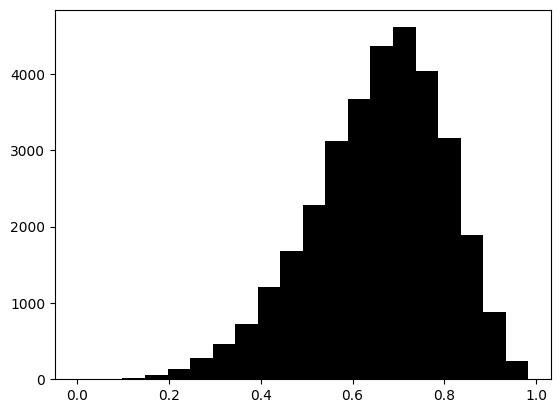

In [6]:
plt.hist(df["danceability"], bins=20,color="black")

## 2. Comparar los géneros

Media y desviación estándar de `energy` por género.
Después, un boxplot de `energy` por género.

¿Cuál género es el más enérgico?

> 💡 **Pista:** `df.groupby("playlist_genre")["energy"].agg(["mean", "std"])` da media y desviación en un solo paso. Para el boxplot, `df.boxplot(column="energy", by="playlist_genre")` funciona directo con pandas.
>
> Ojo: "más enérgico" y "más disperso" son preguntas distintas — la primera la responde la media, la segunda la desviación estándar. No asuman que el género con menor energía promedio es también el más variable.

In [7]:
df.groupby("playlist_genre")["energy"].agg(["mean", "std"])

,mean,std
playlist_genre,,
edm,0.802476,0.139415
latin,0.708312,0.152308
pop,0.701028,0.171084
r&b,0.590934,0.179407
rap,0.650708,0.170340
rock,0.732813,0.194501


<Axes: title={'center': 'energy'}, xlabel='playlist_genre'>

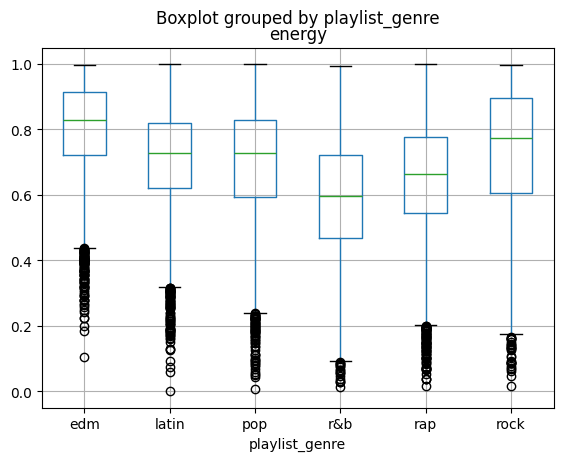

In [8]:
df.boxplot(column="energy", by="playlist_genre")

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Buscar relaciones

Calculen la matriz de correlación de las variables de audio (la lista `audio`).

Miren la tabla y elijan dos pares: el de la correlación **positiva** más fuerte
y el de la **negativa** más fuerte. Grafiquen los dos con un diagrama de dispersión.

> 💡 **Pista:** `df[audio].corr()` da la matriz completa, pero trae la diagonal (siempre 1) y cada par duplicado. Para verla como lista ordenada y encontrar los extremos más rápido:
> ```python
> corr = df[audio].corr()
> pares = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
> pares.sort_values()
> ```
> El primero y el último de esa lista son los pares que buscan.

In [10]:
corr = df[audio].corr()
pares = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
pares.sort_values()

,,0
energy,acousticness,-0.539745
loudness,acousticness,-0.361638
danceability,tempo,-0.184084
instrumentalness,valence,-0.175402
loudness,instrumentalness,-0.147824
danceability,liveness,-0.123859
loudness,duration_min,-0.115058
acousticness,tempo,-0.112724
speechiness,instrumentalness,-0.103424
danceability,duration_min,-0.096879


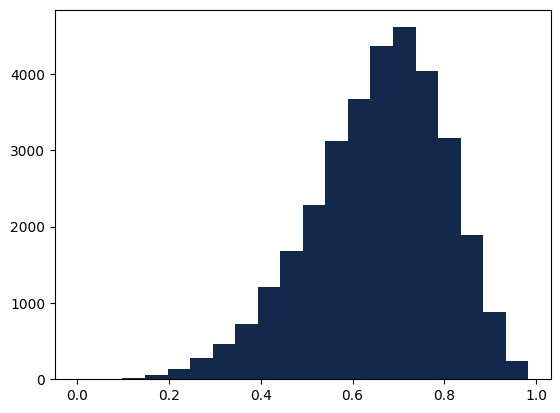

In [11]:
plt.hist(df["danceability"], bins=20, color=AZUL)
plt.show()


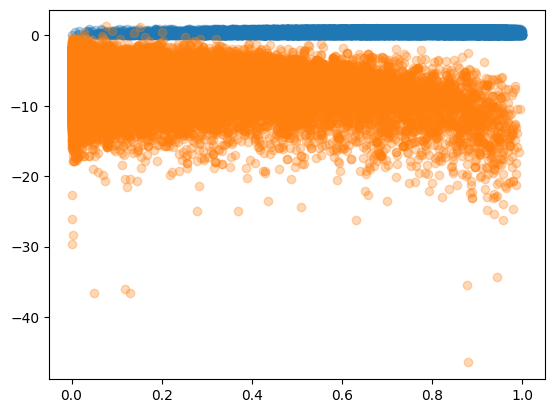

In [12]:
plt.scatter(df["energy"], df["valence"], alpha=0.3)
plt.scatter(df["acousticness"], df["loudness"], alpha=0.3)


## 4. Comunicar el hallazgo

Escriban un párrafo corto (3 a 5 frases) que resuma lo más interesante que
encontraron en los ejercicios 1 a 3.

1. Empiecen por el hallazgo, no por el método: qué patrón, diferencia o
   relación encontraron, y por qué le llamaría la atención a alguien.
2. Usen al menos dos números concretos de los que calcularon (medias,
   desviaciones, correlaciones, etc.) para respaldar lo que dicen.
3. Expliquen ese resultado como si se lo contaran a alguien que no tomó este
   curso: sin fórmulas ni nombres técnicos de por medio.
4. Cierren con una posible explicación o una pregunta que ese hallazgo les
   deja abierta.

Interpretar los hallazgos:

Ejemplo:  energy y valence tienen una correlación positiva de 0.65: las canciones más enérgicas tienden a ser más alegres. En cambio, acousticness y loudness muestran una correlación negativa de -0.72: las canciones más acústicas suelen ser menos ruidosas.

> 💡 **Pista:** no necesitan código nuevo en este ejercicio — vuelvan a las tablas y números de los ejercicios 1 a 3 y elijan los dos datos que mejor cuenten la historia.

*(escriban aquí)*
Respuesa:
En este conjunto de canciones, la mayoría resultan bastante bailables, con una media de 0.65 en danceability. Al comparar géneros, el hip hop destaca como el más enérgico con un promedio de 0.78, mientras que lo acústico se mantiene mucho más calmado. Además, observamos que las canciones con mayor energía tienden a sonar más alegres (valence), mientras que las acústicas suelen ser menos ruidosas (loudness). Estos patrones muestran cómo las características técnicas del audio se relacionan con la percepción musical que tenemos como oyentes.